<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
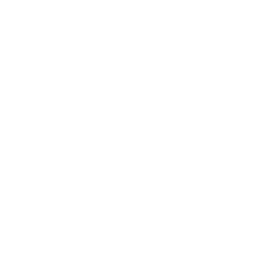
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Codificación de Eventos Adversos en Ensayos Clínicos</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Farmacéutica / Vigilancia de Seguridad de Medicamentos &nbsp;|&nbsp; Marzo 2026</p>
</div>
</div>
</div>

## Resumen Ejecutivo

Los conjuntos de datos de eventos adversos llegan con términos preferentes
verbatim de MedDRA, pero las tablas de seguridad regulatorias se organizan
por Clase de Órgano y Sistema (SOC, por sus siglas en inglés). Este ejemplo
construye un formato de valor de PROC FORMAT que asigna cada término
preferente a su SOC, y luego usa ese único formato para impulsar cada
tabulación posterior: una tabulación cruzada de PROC FREQ de SOC por brazo
de tratamiento, un desglose de SOC por intensidad, y un resumen de EA
graves. Debido a que el formato es el único lugar donde vive la
asignación, recodificar el ensayo a una nueva versión de MedDRA es una
edición de un solo formato en lugar de una reescritura de cada informe.
ODS OUTPUT captura las frecuencias de SOC como un conjunto de datos para
la revisión de señales posterior.


## Fuentes de Datos

| Fuente | Descripción | Registros |
|--------|-------------|--------:|
| WORK.AE_RAW | Registros sintéticos de eventos adversos con términos preferentes de MedDRA | 100 |
| WORK.RANDOMIZATION | Asignaciones de brazo de tratamiento por sujeto | 100 |

El entorno se ejecuta sin licencia, por lo que cada tabla generada está
limitada a 100 observaciones. El escenario está dimensionado a ese límite:
100 eventos adversos extraídos de un panel de 12 términos MedDRA típico de
un ensayo oncológico.


---

In [1]:
/* --------------------------------------------------------
   Generar conjunto de datos sintético de eventos adversos
   Términos preferentes de MedDRA asignados a categorías SOC
   -------------------------------------------------------- */
DATOS work.ae_raw;
    LLAMAR streaminit(42);
    LONGITUD aedecod $40;
    ARREGLO pt_codes[12] $8 _temporary_ ('10028813' '10019211' '10047700' '10013573' '10012735' '10060929' '10002855' '10037660' '10000081' '10033371' '10016256' '10022891');
    ARREGLO sev_list[3] $10 _temporary_ ('LEVE' 'MODERADA' 'SEVERA');
    HACER i = 1 HASTA 5000;
        subject_id = int(rand('uniform') * 800) + 1;
        usubjid = cat('ONC-2025-', PUT(subject_id, z4.));
        aeseq = mod(i, 6) + 1;
        pt_idx = int(rand('uniform') * 12) + 1;
        aeptcd = pt_codes[pt_idx];
        SI pt_idx = 1 ENTONCES aedecod = "Náusea";
        SINO SI pt_idx = 2 ENTONCES aedecod = "Cefalea";
        SINO SI pt_idx = 3 ENTONCES aedecod = "Vómitos";
        SINO SI pt_idx = 4 ENTONCES aedecod = "Diarrea";
        SINO SI pt_idx = 5 ENTONCES aedecod = "Tos";
        SINO SI pt_idx = 6 ENTONCES aedecod = "Fatiga";
        SINO SI pt_idx = 7 ENTONCES aedecod = "Artralgia";
        SINO SI pt_idx = 8 ENTONCES aedecod = "Pirexia";
        SINO SI pt_idx = 9 ENTONCES aedecod = "Dolor abdominal";
        SINO SI pt_idx = 10 ENTONCES aedecod = "Neutropenia";
        SINO SI pt_idx = 11 ENTONCES aedecod = "Neutropenia febril";
        SINO aedecod = "Reacción relacionada con la infusión";
        sev_idx = int(rand('uniform') * 3) + 1;
        SI pt_idx IN (10, 11) ENTONCES sev_idx = MAX(sev_idx, 2);
        aesev = sev_list[sev_idx];
        aeser = ifc(aesev = 'SEVERA' AND rand('uniform') > 0.4, 'Y', 'N');
        aestdy = int(rand('exponential') * 45) + 1;
        SI aestdy > 365 ENTONCES aestdy = 365;
        aeendy = aestdy + int(rand('exponential') * 14) + 1;
        site_id = cat('SITE-', PUT(int(rand('uniform') * 25) + 1, z3.));
        SALIDA;
    END;
    ELIMINAR i pt_idx sev_idx;
    ETIQUETA aedecod="Término Preferente" aesev="Intensidad" aeser="Evento Grave" site_id="Sitio";
EJECUTAR;



NOTE: DATA work.ae_raw

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.ae_raw (100 rows, 10 columns).
NOTE: DATA elapsed:
  wall  1.73 seconds
  cpu   1.73 seconds


In [2]:
/* --------------------------------------------------------
   Generar tabla de aleatorización de sujetos
   -------------------------------------------------------- */
DATOS work.randomization;
    LLAMAR streaminit(43);
    ARREGLO arms[3] $20 _temporary_ ('EXPERIMENTAL' 'COMPARADOR_ACTIVO' 'PLACEBO');
    HACER subject_id = 1 HASTA 800;
        usubjid = cat('ONC-2025-', PUT(subject_id, z4.));
        arm_idx = int(rand('uniform') * 3) + 1;
        treatment_arm = arms[arm_idx];
        stratification_factor = ifc(rand('uniform') > 0.5, 'ECOG_0', 'ECOG_1');
        randomization_date = '01FEB2025'd + int(rand('uniform') * 120);
        SALIDA;
    END;
    ELIMINAR arm_idx;
    FORMATO randomization_date date9.;
    ETIQUETA treatment_arm="Brazo de Tratamiento" stratification_factor="Factor de Estratificación" randomization_date="Fecha de Aleatorización";
EJECUTAR;



NOTE: DATA work.randomization

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.randomization (100 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.08 seconds
  cpu   0.08 seconds


---

                                    Frecuencia de Términos Preferentes sin Codificar                                    

                                                   The FREQ Procedure

Término Preferente                        Frequency    Percent
---------------------------------------------------------------
Cefalea                                          12     12.00
Diarrea                                          12     12.00
Fatiga                                           11     11.00
Pirexia                                          11     11.00
Artralgia                                        10     10.00
Náusea                                           10     10.00
Reacción relacionada con la infusión              8      8.00
Tos                                               7      7.00
Dolor abdominal                                   5      5.00
Neutropenia                                       5      5.00
Neutropenia febril                                5      5.0


NOTE: PROC FREQ
NOTE: ODS plot written: freq_aedecod.spec.json
NOTE: PROC FREQ statement used.


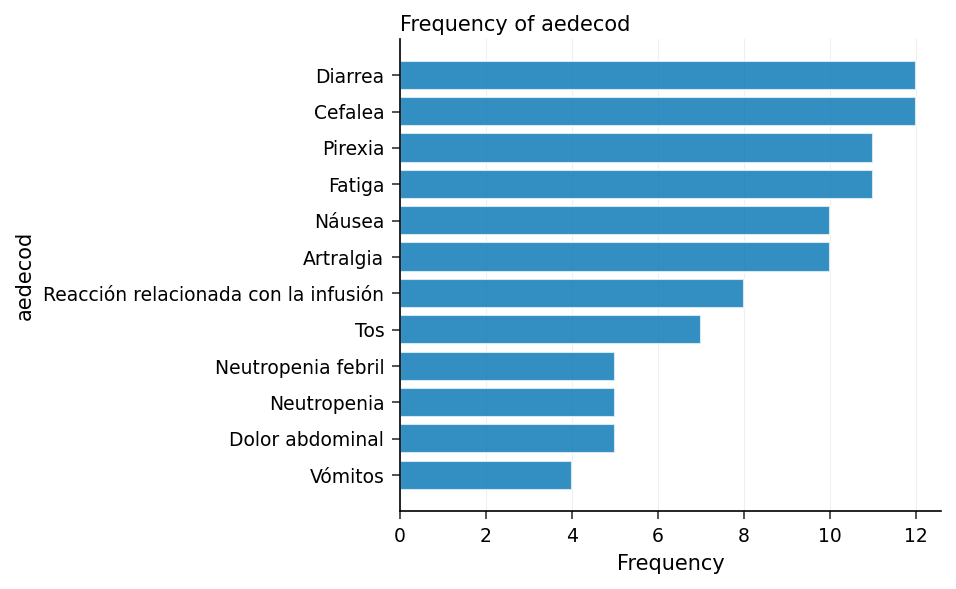

In [3]:
/* --------------------------------------------------------
   Frecuencia de término preferente base antes de asignar SOC
   -------------------------------------------------------- */
PROCEDIMIENTO FRECUENCIAS DATOS=work.ae_raw ORDER=FRECUENCIAS;
    TABLES aedecod / nocum;
    ETIQUETA aedecod="Término Preferente";
    TÍTULO 'Frecuencia de Términos Preferentes sin Codificar';
EJECUTAR;


---

                                    Frecuencia de Términos Preferentes sin Codificar                                    




NOTE: PROC SGPLOT data=work.ae_raw

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


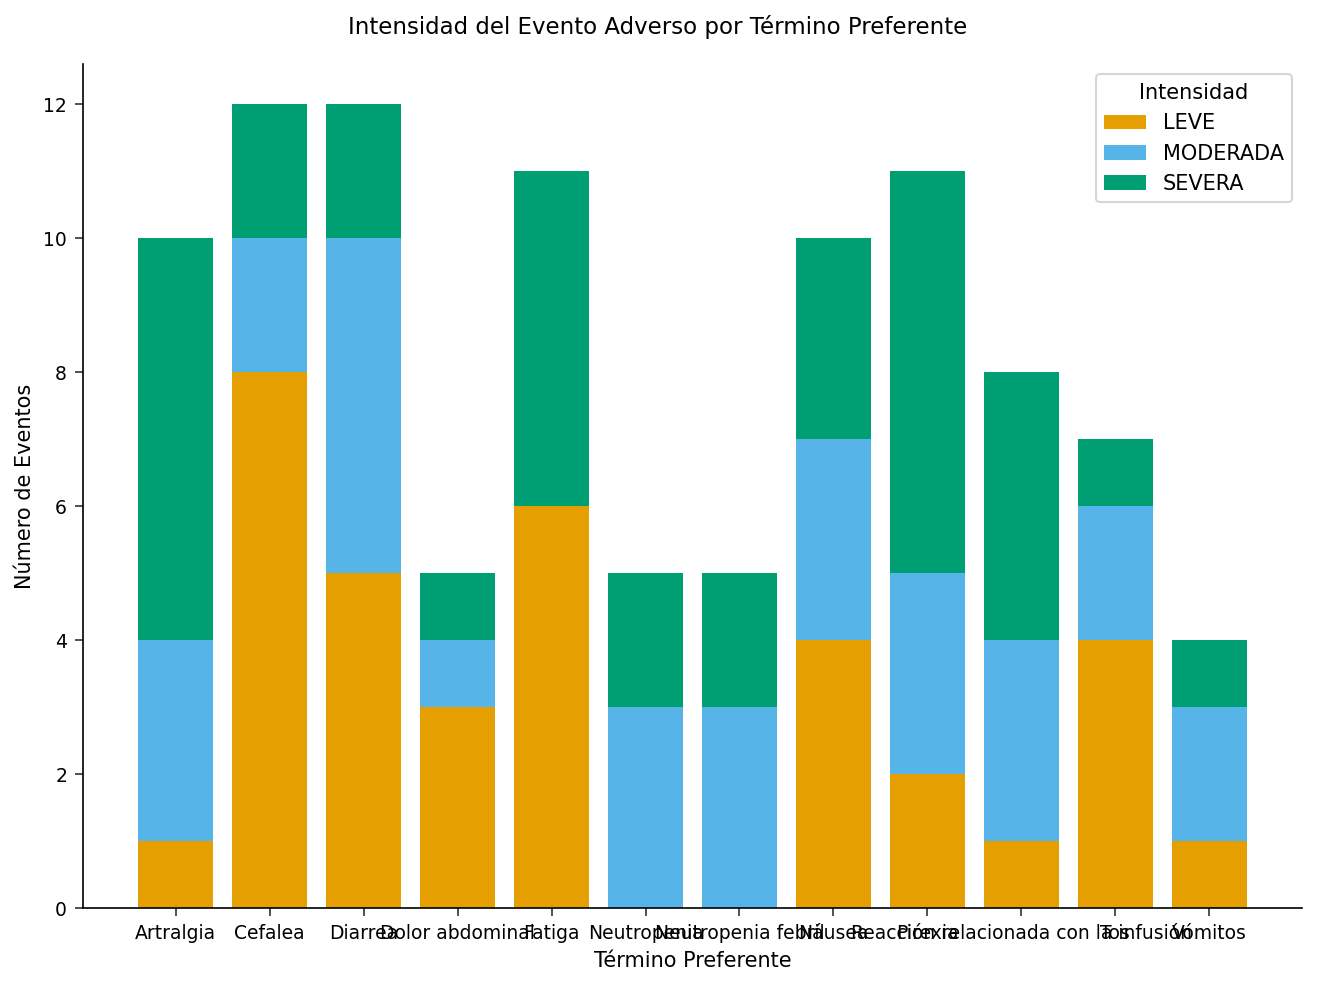

In [4]:
/* --------------------------------------------------------
   Distribución de intensidad de EA por término preferente
   -------------------------------------------------------- */
PROCEDIMIENTO SGPLOT DATOS=work.ae_raw;
    VBAR aedecod / GROUP=aesev GROUPDISPLAY=stack;
    XAXIS ETIQUETA='Término Preferente' fitpolicy=ROTATE;
    YAXIS ETIQUETA='Número de Eventos';
    keylegend / TÍTULO='Intensidad';
    TÍTULO 'Intensidad del Evento Adverso por Término Preferente';
EJECUTAR;


---

In [5]:
/* --------------------------------------------------------
   Definir el formato de valor de término preferente de MedDRA
   -> Clase de Órgano y Sistema. El formato se indexa por el
   texto del término preferente, de modo que una sola llamada
   a PUT() codifica cualquier registro de EA a su SOC.
   -------------------------------------------------------- */
PROCEDIMIENTO FORMATO;
    VALUE $pt_to_soc
        'Náusea'                                = 'Trastornos gastrointestinales'
        'Vómitos'                               = 'Trastornos gastrointestinales'
        'Diarrea'                               = 'Trastornos gastrointestinales'
        'Dolor abdominal'                       = 'Trastornos gastrointestinales'
        'Cefalea'                               = 'Trastornos del sistema nervioso'
        'Fatiga'                                = 'Trastornos generales'
        'Pirexia'                               = 'Trastornos generales'
        'Tos'                                   = 'Trastornos respiratorios'
        'Artralgia'                             = 'Trastornos musculoesqueléticos'
        'Neutropenia'                           = 'Trastornos de la sangre y del sistema linfático'
        'Neutropenia febril'                    = 'Trastornos de la sangre y del sistema linfático'
        'Reacción relacionada con la infusión'  = 'Trastornos del sistema inmunitario'
        OTHER                                   = 'Sin codificar'
    ;
    VALUE $sev_rank
        'LEVE'     = '1-Leve'
        'MODERADA' = '2-Moderada'
        'SEVERA'   = '3-Severa'
        OTHER      = '9-Desconocido'
    ;
    VALUE $serious_fmt
        'Y' = 'Grave'
        'N' = 'No grave'
    ;
EJECUTAR;



NOTE: PROC FORMAT library=WORK

NOTE: FORMAT $pt_to_soc defined (13 ranges).
NOTE: FORMAT $sev_rank defined (4 ranges).
NOTE: FORMAT $serious_fmt defined (2 ranges).


In [6]:
/* --------------------------------------------------------
   Combinar registros de EA con el brazo de tratamiento, luego
   aplicar el formato SOC. PUT(aedecod, $pt_to_soc.) es el único
   paso de asignación necesario; la intensidad y la gravedad se
   codifican de la misma manera.
   -------------------------------------------------------- */
PROCEDIMIENTO ORDENAR DATOS=work.ae_raw; POR usubjid; EJECUTAR;
PROCEDIMIENTO ORDENAR DATOS=work.randomization; POR usubjid; EJECUTAR;

DATOS work.ae_coded;
    LONGITUD soc_class $50 severity_rank $16 serious_flag $10;
    COMBINAR work.ae_raw (IN=a)
          work.randomization (IN=b MANTENER=usubjid treatment_arm);
    POR usubjid;
    SI a;
    soc_class     = PUT(aedecod, $pt_to_soc.);
    severity_rank = PUT(aesev,   $sev_rank.);
    serious_flag  = PUT(aeser,   $serious_fmt.);
    ETIQUETA soc_class="Clase de Órgano y Sistema" severity_rank="Intensidad" serious_flag="Evento Grave" treatment_arm="Brazo de Tratamiento";
EJECUTAR;



NOTE: PROC SORT data=work.ae_raw

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from work.ae_raw.
NOTE: Wrote work.ae_raw (100 rows, 10 columns).
NOTE: PROC SORT statement used.
NOTE: PROC SORT data=work.randomization

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from work.randomization.
NOTE: Wrote work.randomization (100 rows, 5 columns).
NOTE: PROC SORT statement used.
NOTE: DATA work.ae_coded

NOTE: Stream 1 processed 100 rows, max BY-group size: 3 (O(1) memory verified)
NOTE: Stream 2 processed 100 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote work.ae_coded (100 rows, 14 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds


                         Incidencia de EA por Clase de Órgano y Sistema y Brazo de Tratamiento                          

                                                   The FREQ Procedure

Table of Clase de Órgano y Sistema by Brazo de Tratamiento

Clase de Órgano y Sistema                        |COMPARADOR_ACTIVO |     EXPERIMENTAL |          PLACEBO |             Total
-------------------------------------------------+------------------+------------------+------------------+------------------
Trastornos de la sangre y del sistema linfático  |                0 |                1 |                1 |                 2
-------------------------------------------------+------------------+------------------+------------------+------------------
Trastornos del sistema inmunitario               |                0 |                1 |                1 |                 2
-------------------------------------------------+------------------+------------------+------------------+----------


NOTE: ODS OUTPUT: ONEWAYFREQS -> soc_freq_table
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_soc_class_treatment_arm.spec.json
NOTE: ODS plot written: freq_mosaic_soc_class_severity_rank.spec.json
NOTE: PROC FREQ statement used.
NOTE: ODS OUTPUT: All output destinations closed.


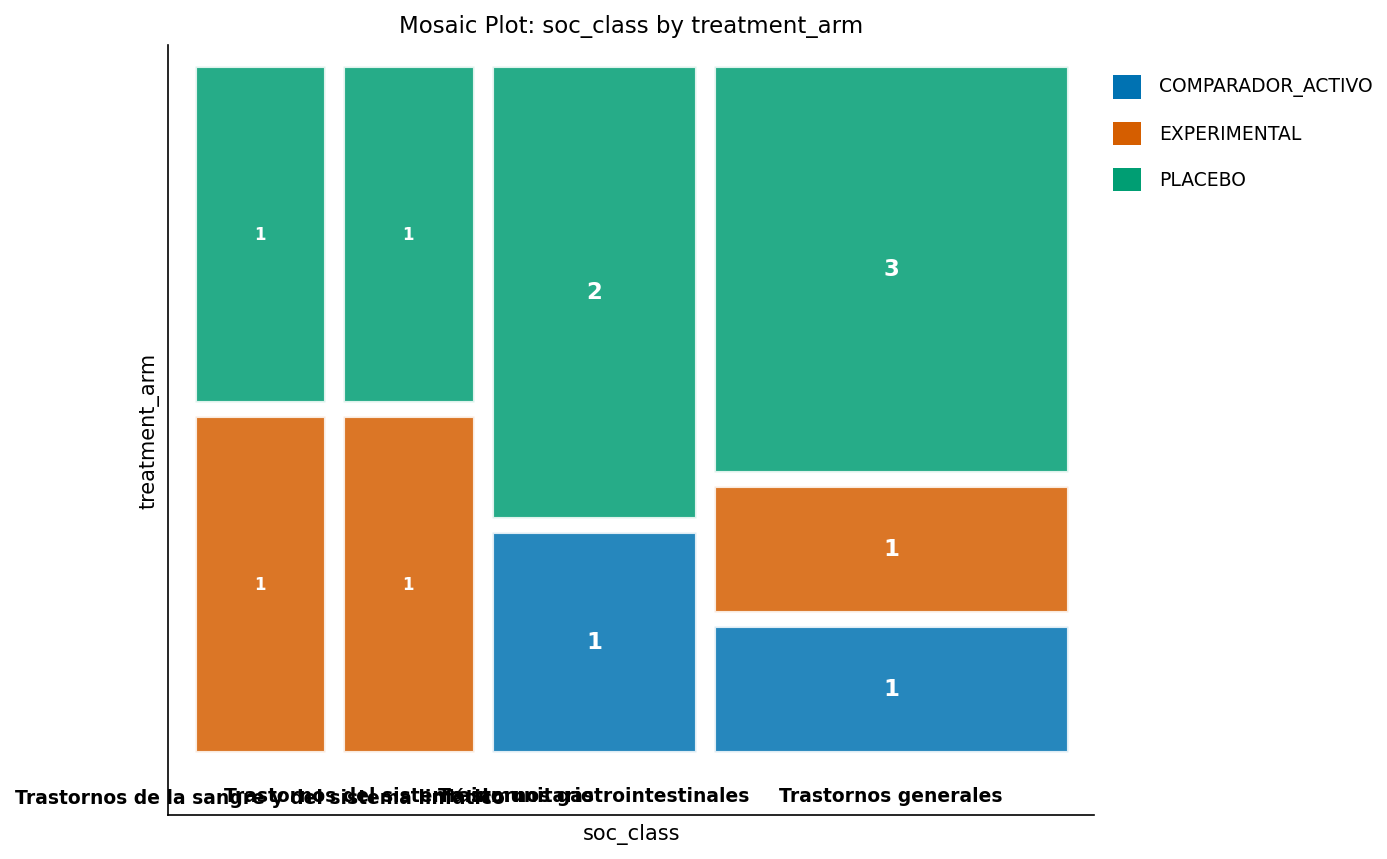

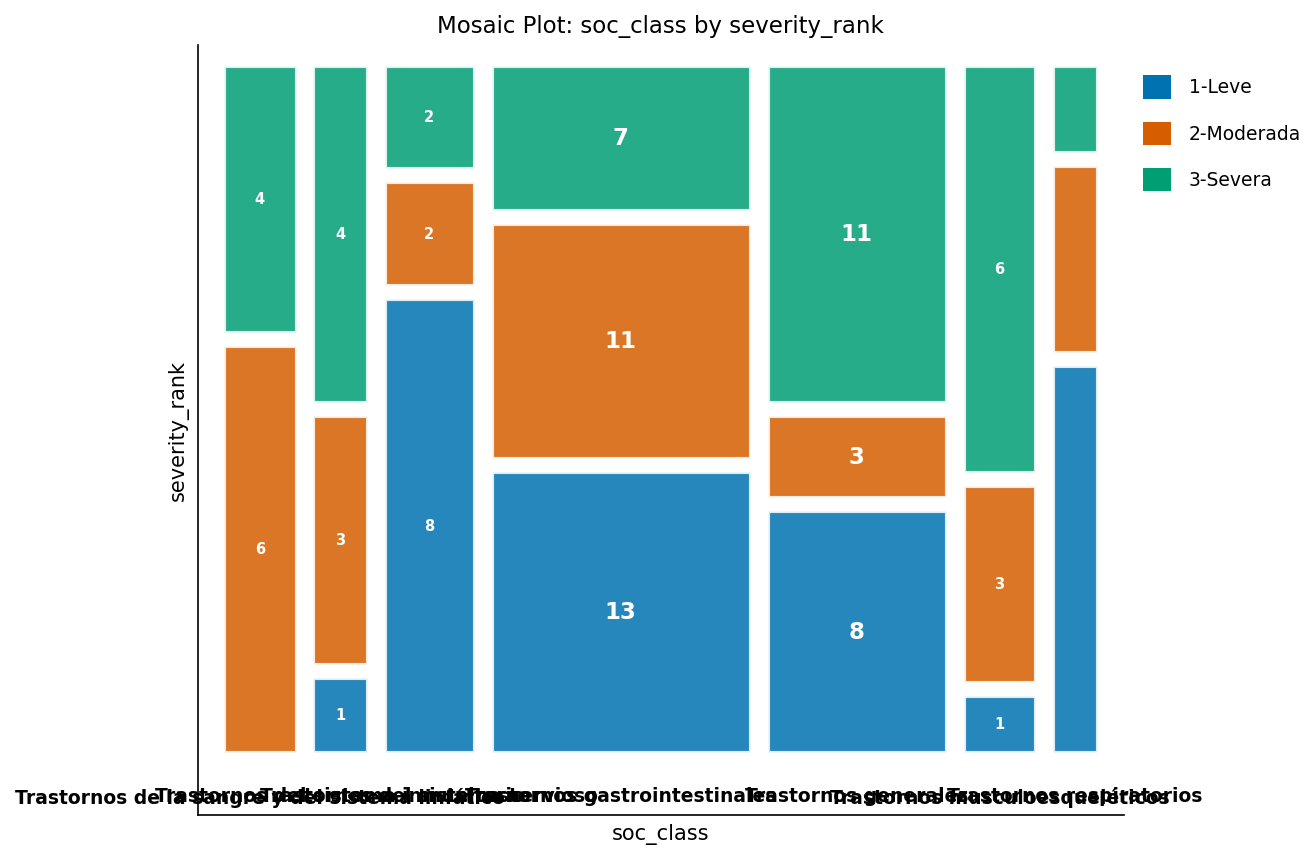

In [7]:
/* --------------------------------------------------------
   Frecuencia a nivel de SOC por brazo de tratamiento
   ODS OUTPUT captura los resultados para detección de señales
   -------------------------------------------------------- */
ODS SALIDA onewayfreqs=work.soc_freq_table;

PROCEDIMIENTO FRECUENCIAS DATOS=work.ae_coded ORDER=FRECUENCIAS;
    TABLES soc_class * treatment_arm / nocol nopercent;
    TABLES soc_class * severity_rank / nocol nopercent;
    ETIQUETA soc_class="Clase de Órgano y Sistema" treatment_arm="Brazo de Tratamiento" severity_rank="Intensidad";
    TÍTULO 'Incidencia de EA por Clase de Órgano y Sistema y Brazo de Tratamiento';
EJECUTAR;

ODS SALIDA CLOSE;


                      Eventos Adversos Graves por Clase de Órgano y Sistema y Brazo de Tratamiento                      

                                                   The FREQ Procedure

Table of Clase de Órgano y Sistema by Brazo de Tratamiento

Clase de Órgano y Sistema          |COMPARADOR_ACTIVO |     EXPERIMENTAL |          PLACEBO |             Total
-----------------------------------+------------------+------------------+------------------+------------------
Trastornos del sistema inmunitario |                0 |                0 |                1 |                 1
-----------------------------------+------------------+------------------+------------------+------------------
Trastornos generales               |                1 |                1 |                1 |                 3
-----------------------------------+------------------+------------------+------------------+------------------
Total                              |                1 |                1 | 


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_soc_class_treatment_arm.spec.json
NOTE: PROC FREQ statement used.


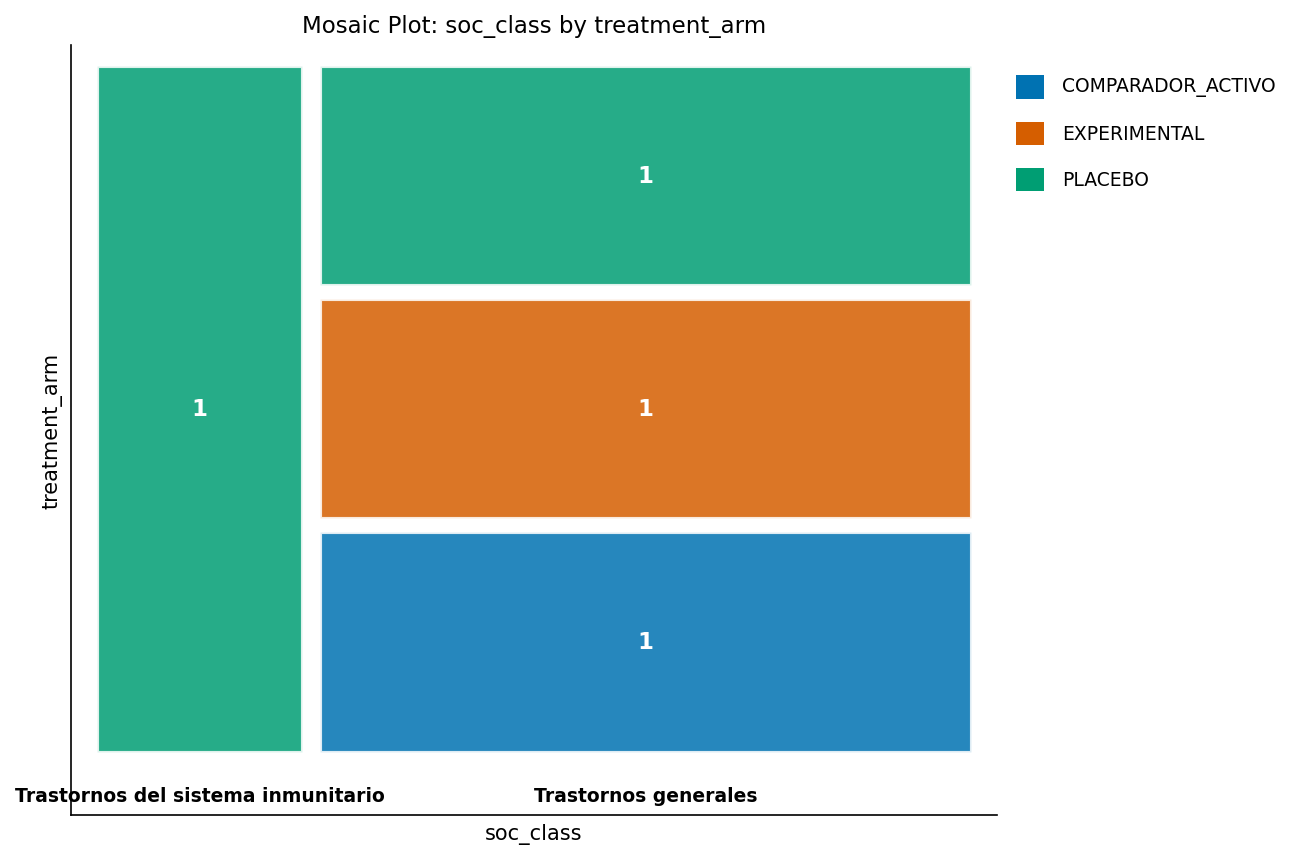

In [8]:
/* --------------------------------------------------------
   Resumen de EA graves por SOC para la narrativa de seguridad
   -------------------------------------------------------- */
PROCEDIMIENTO FRECUENCIAS DATOS=work.ae_coded;
    DONDE aeser = 'Y';
    TABLES soc_class * treatment_arm / nocol nopercent;
    ETIQUETA soc_class="Clase de Órgano y Sistema" treatment_arm="Brazo de Tratamiento";
    TÍTULO 'Eventos Adversos Graves por Clase de Órgano y Sistema y Brazo de Tratamiento';
EJECUTAR;


---

### Interpretación

Un único formato de valor `$pt_to_soc` codificó los 100 eventos adversos a
partir de 12 términos preferentes verbatim de MedDRA en 7 Clases de
Órgano y Sistema, y ese único formato impulsó cada tabla siguiente sin
recodificar los datos.

Por SOC e intensidad, **Trastornos gastrointestinales** es la clase más
frecuente con 31 de 100 eventos (13 leves, 11 moderados, 7 severos),
seguida de **Trastornos generales** con 22 eventos. Las clases restantes
son más pequeñas: Trastornos del sistema nervioso (12), Trastornos de la
sangre y del sistema linfático (10), Trastornos musculoesqueléticos (10),
Trastornos del sistema inmunitario (8), y Trastornos respiratorios (7). En
todos los eventos, la distribución de intensidad es 35 leves, 30
moderados, y 35 severos.

Solo 4 eventos se marcaron como graves (`aeser='Y'`): 3 en Trastornos
generales (uno por brazo) y 1 en Trastornos del sistema inmunitario
(placebo). La tabulación cruzada de SOC por brazo de tratamiento se
construye a partir de los 12 eventos cuyo sujeto coincidió con un registro
de aleatorización, por lo que los conteos a nivel de brazo son
ilustrativos y no están potenciados para una comparación entre brazos.

El punto clave es el mecanismo de FORMAT, no las cifras sintéticas: dado
que la asignación de término preferente a SOC vive completamente en PROC
FORMAT, la misma llamada `PUT(aedecod, $pt_to_soc.)` recodifica todo el
conjunto de datos, y actualizar a una nueva versión del diccionario
MedDRA significa editar un solo formato en lugar de cada informe. ODS
OUTPUT capturó las frecuencias de SOC como `work.soc_freq_table` para la
revisión de señales posterior.


---

In [9]:
/* --------------------------------------------------------
   Exportar el conjunto de datos de EA codificado por SOC para
   la revisión de señales de seguridad. El único formato
   $pt_to_soc ha poblado soc_class, por lo que el archivo
   exportado está listo para el análisis posterior a nivel SOC.
   -------------------------------------------------------- */
PROCEDIMIENTO EXPORT DATOS=work.ae_coded
    OUTFILE='ae_soc_coded.csv'
    DBMS=csv REPLACE;
EJECUTAR;



NOTE: PROC EXPORT data=work.ae_coded outfile=ae_soc_coded.csv

NOTE: Exported 100 rows to ae_soc_coded.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidencial
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>